##Refatoração: De NumPy para PyTorch (Tensores)
Autor: Leandro Belo de Almeida Gomes

Objetivo: Converter o script utilizado no *"Estudo de caso 01: Fundamentos da Classificação Linear"* em um código que utiliza a estrutura real do PyTorch.

Neste caso, demonstro a transição de operações manuais para o ecossistema de alto desempenho do PyTorch, focando em agnosticismo de hardware e vetorização de dados.

##1. Configuração do Ambiente e Gerenciamento de Hardware
Nesta etapa, é preparado o script para ser executado de forma agnóstica. O código identifica se há uma GPU disponível, garantindo máxima performance, ou utiliza a CPU como redundância.

In [1]:
import torch
import matplotlib.pyplot as plt

def configurar_dispositivo() -> torch.device:
    """Define se o código rodará na GPU ou CPU."""
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Executando em: {device}")
    return device

def preparar_dados(lista: list, dispositivo: torch.device) -> torch.Tensor:
    """Converte listas em tensores float32 no dispositivo correto."""
    return torch.tensor(lista, dtype=torch.float32).to(dispositivo)
# Fixar a Seed para garantir que o resultado seja o mesmo sempre.
torch.manual_seed(42)

##2. Preparação e Vetorização dos Dados
Aqui, é convertido listas nativas do Python para Tensores PyTorch. Utilizamos o tipo de dado float32, que é o padrão da indústria para redes neurais, garantindo a precisão necessária para os cálculos de gradiente.

In [9]:
def carregar_dados(lista: list, dispositivo: torch.device) -> torch.Tensor:
    """Converte listas em tensores float32 no hardware alvo."""
    return torch.tensor(lista, dtype=torch.float32).to(dispositivo)

# Dados de entrada (Coordenadas X, Y)
pontos_lista = [[1.0, 2.0], [3.0, 4.0], [5.0, 1.0]]
pontos_tensor = carregar_dados(pontos_lista, device)

##3. Implementação da Lógica de Predição Linear
A predição é baseada na operação fundamental de álgebra linear: $y = x \cdot W + b$. Ao isolar esta lógica em uma função, será facilitada a manutenção e futuros testes unitários do modelo

In [3]:
def calcular_predicao(x: torch.Tensor, w: torch.Tensor, b: torch.Tensor) -> torch.Tensor:
    """
    Executa a operação fundamental do neurônio linear: y = xW + b
    Args:
        x: Tensor de entrada (pontos)
        w: Pesos (weights)
        b: Viés (bias)
    """
    return torch.matmul(x, w) + b

##4. Definição de Parâmetros e Inferência
Nesta seção, é definido manualmente os pesos ($W$) e o viés ($b$) para validar a fronteira de decisão. Os tensores são criados diretamente no dispositivo (device) configurado inicialmente.

In [11]:
# Pesos manuais para teste de classificação
w = torch.tensor([[-1.0], [4.0]], device=device)
b = torch.tensor([-0.4], device=device)

# Execução da predição
resultados = calcular_predicao(pontos_tensor, w, b)

print("--- Resultados da Predição ---")
print(resultados)

--- Resultados da Predição ---
tensor([[ 6.6000],
        [12.6000],
        [-1.4000]], device='cuda:0')


##5. Análise Visual e Espacial
A visualização é crucial para validar se a lógica matemática condiz com a posição dos pontos no espaço vetorial. Certificando de mover os dados de volta para a CPU antes da plotagem para evitar conflitos de biblioteca.

Ponto 1: Retorno 6.60 -> Acima da reta
Ponto 2: Retorno 12.60 -> Acima da reta
Ponto 3: Retorno -1.40 -> Abaixo da reta


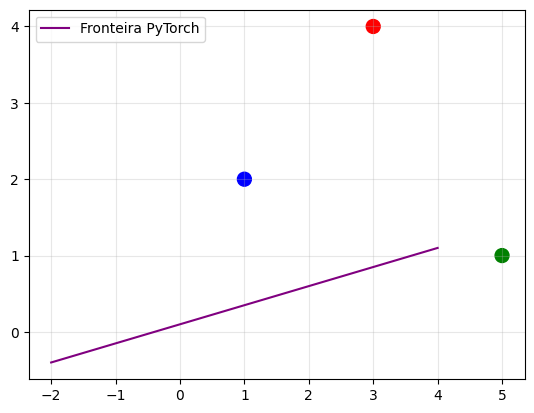

In [12]:
import matplotlib.pyplot as plt

# Sempre usar .detach().cpu() antes de converter para numpy ou plotar
plt.scatter(pontos_tensor.cpu()[:, 0], pontos_tensor.cpu()[:, 1])
for i, ret in enumerate(resultados.squeeze()):
    classe = "Acima" if ret > 0 else "Abaixo"
    print(f"Ponto {i+1}: Retorno {ret.item():.2f} -> {classe} da reta")

# Visualização (Convertendo de volta para numpy apenas para o gráfico)
def plot_pytorch_frontier(w, b):
    x_val = torch.linspace(-2, 4, 50).to(w.device)
    # Isolando y: y = (-w[0]*x - b) / w[1]
    y_val = (-w[0] * x_val - b) / w[1]

    plt.plot(x_val.cpu().numpy(), y_val.cpu().numpy(), label='Fronteira PyTorch', color='purple')
    plt.scatter(pontos_tensor.cpu()[:, 0], pontos_tensor.cpu()[:, 1], c=['blue', 'red', 'green'], s=100)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

plot_pytorch_frontier(w, b)